# 05: Execution-based metrics (DEFERRED)

Does the translation preserve semantics? Oracle = the gold **SQL on Postgres**; compared against the generated query run on the graph DB, as multisets (Execution Accuracy / precision / recall / F1 / Jaccard).

**This notebook is DEFERRED in the first pass and gated behind `EVAL_EXECUTION=1`.** Prerequisites:

- graphonauts2 **Postgres** up (port 5433, db/user `graphonaut`) loaded with LDBC SF1.
- **Neo4j** up (`bolt://localhost:7687`, `NEO4J_PASSWORD`) loaded with LDBC SF1 (Cypher target).
- **ArangoDB** (`db ldbc`, `ARANGO_PASSWORD`) only when an AQL row is added.
- **Datetime (formerly defect D7)**: graphonauts2 now loads `creationDate`/`birthday`/`joinDate` into Neo4j as **native temporal types** (`DateTime`/`Date`), so gold and generated `datetime('...')` / `date('...')` predicates match directly, and date output columns are reconciled by `_to_epoch_ms` (which handles Neo4j temporals via `.to_native()`). Reload Neo4j after the loader change before trusting results.

Enable with: `export NEO4J_PASSWORD=... EVAL_EXECUTION=1` then run. Comparison is **positional** (RETURN column order must match the SQL SELECT order).

In [1]:
from __future__ import annotations
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "pyproject.toml").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "evaluation"))

import json, os
from collections import Counter
from datetime import date, datetime
from time import perf_counter
from typing import Any
import pandas as pd
from eval_harness import load_records, OUTPUTS_DIR

EXECUTION_ENABLED = os.environ.get('EVAL_EXECUTION', '0') == '1'
if not EXECUTION_ENABLED:
    print('Execution metrics are DEFERRED. To enable:')
    print('  1. Bring up graphonauts2 Postgres (5433, graphonaut) and Neo4j (7687), each with LDBC SF1.')
    print('  2. export NEO4J_PASSWORD=... and EVAL_EXECUTION=1, then re-run.')
    print('  3. Reload Neo4j with the native-temporal loader before trusting date-predicate results.')
    raise SystemExit('EVAL_EXECUTION not set; skipping execution metrics.')

OUT_CSV = OUTPUTS_DIR / 'metrics_execution.csv'
CACHE_PATH = OUTPUTS_DIR / 'execution_rows_cache.json'
STATEMENT_TIMEOUT_S = int(os.environ.get('EVAL_QUERY_TIMEOUT', '30'))
print(f'Per-query timeout: {STATEMENT_TIMEOUT_S}s')

Per-query timeout: 30s


## Connection configs and DB availability map

Which `(dataset, target)` cells can be executed: the dataset needs a Postgres oracle, the target needs a graph DB. Extend when AQL/Arango or a TPC-H Postgres land.

In [2]:
PG_DSN = (
    f"host={os.environ.get('POSTGRES_HOST','localhost')} "
    f"port={os.environ.get('POSTGRES_PORT','5433')} "
    f"user={os.environ.get('POSTGRES_USER','graphonaut')} "
    f"password={os.environ.get('POSTGRES_PASSWORD','password')} "
    f"dbname={os.environ.get('POSTGRES_DB','graphonaut')}"
)
NEO4J_URI = os.environ.get('NEO4J_URI', 'bolt://localhost:7687')
NEO4J_USER = os.environ.get('NEO4J_USER', 'neo4j')
NEO4J_DB = os.environ.get('NEO4J_DATABASE', 'neo4j')

POSTGRES_DATASETS = {'ldbc'}        # datasets with a loaded Postgres oracle
TARGET_DB = {'cypher': 'neo4j'}     # add 'aql': 'arangodb' when ArangoDB is loaded
assert os.environ.get('NEO4J_PASSWORD'), 'Export NEO4J_PASSWORD before running this notebook.'

## Row normalisation

Canonicalise every driver value to a string so multiset comparison works across Postgres / Neo4j drivers.

In [3]:
import datetime as _dt
from neo4j.time import Date as Neo4jDate, DateTime as Neo4jDateTime

def _to_epoch_ms(v):
    # Canonicalise a date-typed value to epoch-millis so Postgres timestamps and
    # Neo4j's temporal (DateTime/Date) storage compare equal. Handles Neo4j
    # temporals, stdlib datetime/date, ISO strings (from the JSON reference
    # cache), and pass-through ints (legacy epoch-millis storage).
    if isinstance(v, (Neo4jDate, Neo4jDateTime)):
        v = v.to_native()  # Neo4j temporal -> stdlib date/datetime, handled below
    if isinstance(v, _dt.datetime):
        if v.tzinfo is None:
            v = v.replace(tzinfo=_dt.timezone.utc)
        return int(v.timestamp() * 1000)
    if isinstance(v, _dt.date):
        return int(_dt.datetime(v.year, v.month, v.day, tzinfo=_dt.timezone.utc).timestamp() * 1000)
    if isinstance(v, str):
        try:
            s = v.replace(' ', 'T').split('+')[0]
            dtv = _dt.datetime.fromisoformat(s if 'T' in s else s + 'T00:00:00')
            return int(dtv.replace(tzinfo=_dt.timezone.utc).timestamp() * 1000)
        except ValueError:
            return v
    return v

def _date_columns(rows):
    # Column positions the oracle (Postgres) returns as date/datetime.
    cols = set()
    for r in rows:
        vals = list(r.values()) if isinstance(r, dict) else list(r)
        for j, v in enumerate(vals):
            if isinstance(v, (_dt.date, _dt.datetime)):
                cols.add(j)
    return cols

def _norm_value(v):
    if v is None:
        return None
    if isinstance(v, bool):
        return 'True' if v else 'False'
    if isinstance(v, (Neo4jDate, Neo4jDateTime)):
        return v.iso_format().split('+')[0].split('[')[0]
    if isinstance(v, _dt.datetime):
        return v.replace(tzinfo=None).isoformat(timespec='seconds')
    if isinstance(v, _dt.date):
        return v.isoformat()
    if isinstance(v, int):
        return str(v)
    if isinstance(v, float):
        as_int = int(v)
        return str(as_int) if abs(v - as_int) < 1e-9 else f'{v:.6f}'
    s = str(v)
    if len(s) >= 19 and s[4] == '-' and s[7] == '-' and (s[10] == 'T' or s[10] == ' '):
        return s.replace(' ', 'T')[:19]
    return s

def _norm_row(row, date_cols=frozenset()):
    vals = list(row.values()) if isinstance(row, dict) else list(row)
    return tuple(str(_to_epoch_ms(v)) if (j in date_cols and v is not None) else _norm_value(v)
                 for j, v in enumerate(vals))

## Multiset comparison

In [4]:
def compare_rowsets(ref_rows, trans_rows, date_cols=frozenset()):
    # Oracle (Postgres) defines which columns are dates; reconcile Neo4j epoch-millis there.
    ref = Counter(_norm_row(r, date_cols) for r in ref_rows)
    trans = Counter(_norm_row(r, date_cols) for r in trans_rows)
    overlap = sum((ref & trans).values())
    n_ref = sum(ref.values()); n_trans = sum(trans.values()); union = sum((ref | trans).values())
    precision = overlap / n_trans if n_trans else (1.0 if n_ref == 0 else 0.0)
    recall = overlap / n_ref if n_ref else (1.0 if n_trans == 0 else 0.0)
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return {
        'execution_accuracy': 1.0 if ref == trans else 0.0,
        'result_precision': precision, 'result_recall': recall, 'result_f1': f1,
        'result_jaccard_dist': 1.0 - (overlap / union) if union else 0.0,
        'reference_rows': n_ref, 'translated_rows': n_trans,
    }

## Query executors

`run_cypher` uses `neo4j.Query(..., timeout=...)` (the correct neo4j>=5 way to bound a query; `session.run` takes no `timeout` kwarg).

In [5]:
import psycopg
from neo4j import GraphDatabase, Query

def run_postgres(sql):
    t0 = perf_counter()
    try:
        with psycopg.connect(PG_DSN) as conn, conn.cursor() as cur:
            cur.execute(f'SET LOCAL statement_timeout = {STATEMENT_TIMEOUT_S * 1000}')
            cur.execute(sql)
            rows = cur.fetchall()
    except Exception as exc:
        return [], perf_counter() - t0, f'{type(exc).__name__}: {exc}'
    return rows, perf_counter() - t0, None

_neo4j_driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, os.environ['NEO4J_PASSWORD']))

def run_cypher(query):
    t0 = perf_counter()
    try:
        with _neo4j_driver.session(database=NEO4J_DB) as session:
            result = session.run(Query(query, timeout=STATEMENT_TIMEOUT_S))
            rows = [r.data() for r in result]
    except Exception as exc:
        return [], perf_counter() - t0, f'{type(exc).__name__}: {exc}'
    return rows, perf_counter() - t0, None

RUNNERS = {'cypher': run_cypher}  # add 'aql': run_aql when ArangoDB is loaded

## Reference-row cache

Keyed by `(dataset, query_id)` so the same query id across datasets does not collide. Delete `execution_rows_cache.json` to refresh.

In [6]:
cache = json.loads(CACHE_PATH.read_text()) if CACHE_PATH.exists() else {}
print(f'Reference cache: {len(cache)} entries.')

Reference cache: 0 entries.


## Main loop

Keeps only records whose `(dataset, target)` is executable; others are skipped with a reason.

In [7]:
records = load_records(OUTPUTS_DIR)
runnable = [r for r in records if r['dataset'] in POSTGRES_DATASETS and r['target'] in TARGET_DB]
print(f'Executable records: {len(runnable)} / {len(records)} (need Postgres oracle + graph DB).')

rows_out = []
for idx, rec in enumerate(runnable, start=1):
    qid = rec['query_id']; ckey = f"{rec['dataset']}:{qid}"
    print(f'[{idx:3d}/{len(runnable)}] {qid} ({rec["target"]})', end=' ', flush=True)
    if ckey in cache:
        ref_rows = [tuple(r) for r in cache[ckey]['rows']]; ref_runtime = cache[ckey]['runtime']
        ref_error = cache[ckey].get('error'); dcols = set(cache[ckey].get('date_cols', []))
    else:
        ref_rows, ref_runtime, ref_error = run_postgres(rec['sql'])
        dcols = sorted(_date_columns(ref_rows))
        cache[ckey] = {'rows': [list(r) for r in ref_rows], 'runtime': ref_runtime,
                       'error': ref_error, 'date_cols': dcols}
        CACHE_PATH.write_text(json.dumps(cache, default=str)); dcols = set(dcols)
    out = {'dataset': rec['dataset'], 'target': rec['target'], 'model': rec['model'],
           'query_id': qid, 'difficulty': rec['difficulty'], 'validation_passed': rec['validation_passed'],
           'reference_runtime_s': ref_runtime, 'reference_error': ref_error, 'translated_runtime_s': None,
           'execution_error': None, 'execution_accuracy': 0.0, 'result_precision': 0.0,
           'result_recall': 0.0, 'result_f1': 0.0, 'result_jaccard_dist': 1.0,
           'reference_rows': len(ref_rows), 'translated_rows': 0}
    if ref_error is not None:
        print(f'REF ERROR ({ref_error})'); rows_out.append(out); continue
    if not rec['validation_passed'] or not rec.get('generated_query'):
        print('skip (translation invalid)'); rows_out.append(out); continue
    trans_rows, trans_runtime, trans_error = RUNNERS[rec['target']](rec['generated_query'])
    out['translated_runtime_s'] = trans_runtime; out['execution_error'] = trans_error
    if trans_error is not None:
        print(f'EXEC ERROR ({trans_error[:60]})'); rows_out.append(out); continue
    out.update(compare_rowsets(ref_rows, trans_rows, dcols))
    marker = 'ok' if out['execution_accuracy'] == 1.0 else 'ne'
    print(f"{marker} EX={out['execution_accuracy']:.0f} F1={out['result_f1']:.2f} "
          f"ref={out['reference_rows']} trans={out['translated_rows']}")
    rows_out.append(out)
exec_df = pd.DataFrame(rows_out)
print('Done.')

Executable records: 56 / 56 (need Postgres oracle + graph DB).
[  1/56] ldbc_q01 (cypher) 

ok EX=1 F1=1.00 ref=1 trans=1
[  2/56] ldbc_q02 (cypher) 

ok EX=1 F1=1.00 ref=12932 trans=12932
[  3/56] ldbc_q03 (cypher) 

ok EX=1 F1=1.00 ref=4 trans=4
[  4/56] ldbc_q04 (cypher) 

ok EX=1 F1=1.00 ref=10 trans=10
[  5/56] ldbc_q05 (cypher) 

...

Received notification from DBMS server: <GqlStatusObject gql_status='01N52', status_description='warn: property key does not exist. The property `forum_id` does not exist. Verify that the spelling is correct.', position=<SummaryInputPosition line=2, column=10, offset=52>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 52, 'line': 2, 'column': 10}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'MATCH (p:Person)-[:HAS_CREATOR]->(po:Post)\nWHERE po.forum_id = 549755813888\nRETURN DISTINCT p.id, p.firstName, p.lastName\nUNION\nMATCH (p:Person)-[:LIKES]->(l:Post)-[:HAS_CREATOR]->(po:Post)\nWHERE po.forum_id = 549755813888\nRETURN DISTINCT p.id, p.firstName, p.lastName'


Received notification from DBMS server: <GqlStatusObject gql_status='01N52', status_description='warn: property key does not exist. The property `forum_id` does not exist. Verify that the spelling is correct.', position=<SummaryInputPosition line=6, column=10, offset=199>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 199, 'line': 6, 'column': 10}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'MATCH (p:Person)-[:HAS_CREATOR]->(po:Post)\nWHERE po.forum_id = 549755813888\nRETURN DISTINCT p.id, p.firstName, p.lastName\nUNION\nMATCH (p:Person)-[:LIKES]->(l:Post)-[:HAS_CREATOR]->(po:Post)\nWHERE po.forum_id = 549755813888\nRETURN DISTINCT p.id, p.firstName, p.lastName'


ok EX=1 F1=1.00 ref=0 trans=0
[ 55/56] ldbc_q13 (cypher) 

ok EX=1 F1=1.00 ref=1642 trans=1642
[ 56/56] ldbc_q14 (cypher) 

ne EX=0 F1=0.00 ref=111 trans=0
Done.


## Summaries and save

In [8]:
metric_cols = ['execution_accuracy','result_precision','result_recall','result_f1','result_jaccard_dist']
if len(exec_df):
    print('By dataset x target x model:')
    display(exec_df.groupby(['dataset','target','model'])[metric_cols].mean())
exec_df.to_csv(OUT_CSV, index=False)
print(f'Wrote {len(exec_df)} rows to {OUT_CSV}')
_neo4j_driver.close()

By dataset x target x model:


execution_accuracy  result_precision  \
dataset target model                                                   
ldbc    cypher claude-opus-4-8            1.000000          1.000000   
               gemma4:26b                 1.000000          1.000000   
               llama3.2:latest            0.285714          0.294414   
               qwen3-coder:30b            0.714286          0.722986   

                                result_recall  result_f1  result_jaccard_dist  
dataset target model                                                           
ldbc    cypher claude-opus-4-8       1.000000   1.000000             0.000000  
               gemma4:26b            1.000000   1.000000             0.000000  
               llama3.2:latest       0.294414   0.294414             0.709654  
               qwen3-coder:30b       0.722986   0.722986             0.281082

Wrote 56 rows to /Users/ivona.obonova/school/rows2graph/rows2graph/evaluation/outputs/metrics_execution.csv


## Visualizations: execution accuracy across models / queries

Per-query execution-accuracy matrix (did the generated query return the correct rows?) and per-model execution accuracy / result F1. Only runs when `EVAL_EXECUTION=1`.

In [9]:
from eval_harness import plots, REPORTS_DIR
FIG_DIR = REPORTS_DIR / 'figures'; FIG_DIR.mkdir(parents=True, exist_ok=True)
MODELS = plots.model_axis(exec_df); QUERIES = plots.query_axis(exec_df)
print(f'{len(MODELS)} model(s): {MODELS}')

4 model(s): ['claude-opus-4-8', 'gemma4:26b', 'llama3.2:latest', 'qwen3-coder:30b']


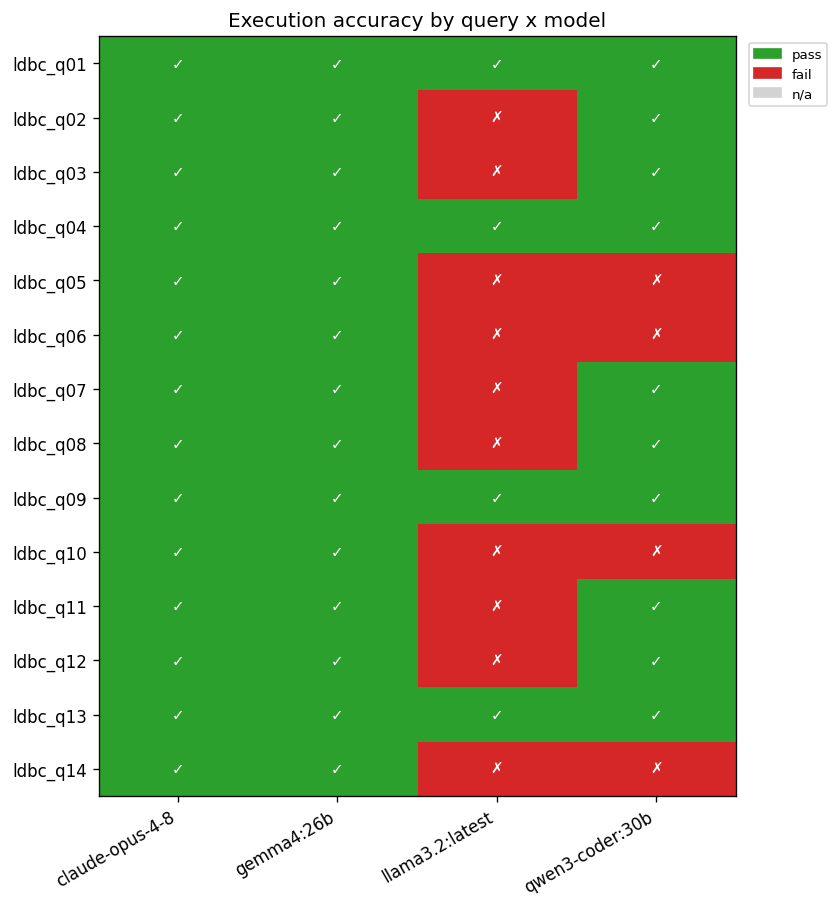

In [10]:
# The per-query semantic view: did each model's query return the correct rows?
p = FIG_DIR / 'query_model_exec.png'
plots.query_model_heatmap(exec_df, 'execution_accuracy', p, discrete=True, models=MODELS, queries=QUERIES,
                          title='Execution accuracy by query x model', cbar_label='exec acc')
plots.show(p)

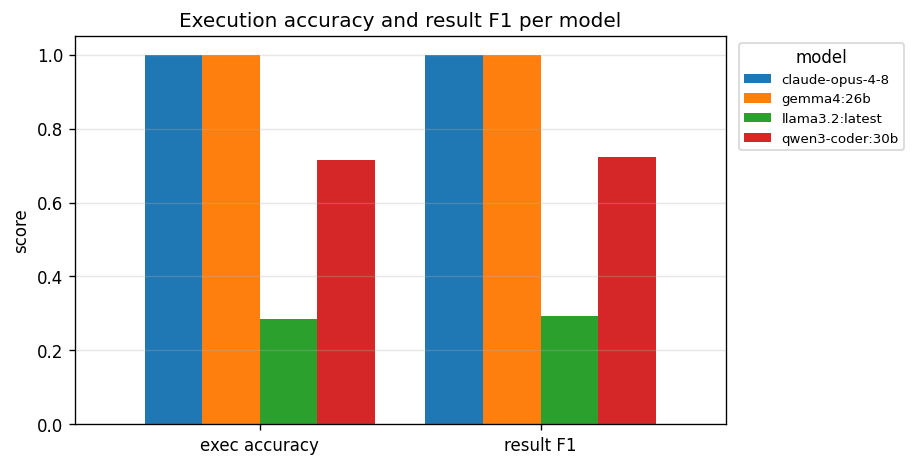

In [11]:
# Per-model execution accuracy and result F1 (semantic correctness against the SQL oracle).
p = FIG_DIR / 'execution_bars.png'
plots.per_model_bars(exec_df, ['execution_accuracy', 'result_f1'], p,
                     title='Execution accuracy and result F1 per model', ylabel='score',
                     labels={'execution_accuracy': 'exec accuracy', 'result_f1': 'result F1'})
plots.show(p)